In [48]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
import os
load_dotenv()
token=os.getenv('Hugging_Face_Token')
print("Token is",token is not None)

Token is True


In [49]:
llm=HuggingFaceEndpoint(
     repo_id="Qwen/Qwen3-8B",
        task="text-generation",
        max_new_tokens=512,
        temperature=0.7,
        huggingfacehub_api_token=token,
)
model=ChatHuggingFace(llm=llm)

In [50]:
class Cricket(TypedDict):
    runs:int
    fours:int
    six:int
    balls:int
    sr:float
    bpb:float
    boundary_percent:float
    summary:str

In [51]:
def boundary_per_ball(state:Cricket) :
    boundarys=state['fours']+state['six']
    balls=state['balls']
    return {'bpb':round(boundarys/balls,2)}
    #return state


In [52]:
def strike_rate(state:Cricket) :
    runs=state['runs']
    balls=state['balls']
    return {'sr':round(runs/balls,2)*100}
    #return state

In [53]:
def boundaryPercent(state:Cricket)-> Cricket:
    runs=state['runs']
    runsbo=state['fours']*4 +state['six']*6
    return {'boundary_percent':round(runsbo/runs,2)}

    #return state

In [54]:
def Summarise(state:Cricket) ->Cricket:
    summary=f"The player Scored {state['runs']} runs in {state['balls']} balls with a strike rate of {state['sr']} \n.The boundaries are as follows with {state['fours']} fours and {state['six']} with boundary per ball {state['bpb']} and boundary percentage is {state['boundary_percent']} "
    state['summary']=summary
    return state

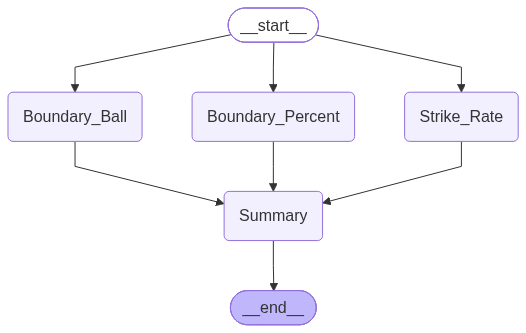

In [55]:
graph=StateGraph(Cricket)

graph.add_node('Boundary_Ball',boundary_per_ball)
graph.add_node('Strike_Rate',strike_rate)
graph.add_node('Boundary_Percent',boundaryPercent)
graph.add_node('Summary',Summarise)

graph.add_edge(START,'Boundary_Ball')
graph.add_edge(START,'Strike_Rate')
graph.add_edge(START,'Boundary_Percent')

graph.add_edge('Boundary_Ball','Summary')
graph.add_edge('Strike_Rate','Summary')
graph.add_edge('Boundary_Percent','Summary')

graph.add_edge('Summary',END)

graph.compile()



In [56]:
workflow=graph.compile()
player_details = {
    "runs": 200,
    "fours": 10,
    "six": 8,
    "balls": 158
}

answer = workflow.invoke(player_details)

print(answer['summary'])

The player Scored 200 runs in 158 balls with a strike rate of 127.0 
.The boundaries are as follows with 10 fours and 8 with boundary per ball 0.11 and boundary percentage is 0.44 
